In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
%matplotlib inline

In [2]:
df = pd.read_csv('data.csv')
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


In [3]:
print(df.info())
print('\n')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  object 
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 5.2+ MB
None


Rows: 62184, Columns: 11


In [4]:
df.isnull().sum()

number_people           0
date                    0
timestamp               0
day_of_week             0
is_weekend              0
is_holiday              0
temperature             0
is_start_of_semester    0
is_during_semester      0
month                   0
hour                    0
dtype: int64

In [6]:
print(df.duplicated().sum())

0


In [7]:
df.describe()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
count,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000
mean,29.072543,45799.437958,2.982504,0.282870,0.002573,58.557108,0.078831,0.660218,7.439824,12.236460
std,22.689026,24211.275891,1.996825,0.450398,0.050660,6.316396,0.269476,0.473639,3.445069,6.717631
min,0.000000,0.000000,0.000000,0.000000,0.000000,38.140000,0.000000,0.000000,1.000000,0.000000
25%,9.000000,26624.000000,1.000000,0.000000,0.000000,55.000000,0.000000,0.000000,5.000000,7.000000
50%,28.000000,46522.500000,3.000000,0.000000,0.000000,58.340000,0.000000,1.000000,8.000000,12.000000
75%,43.000000,66612.000000,5.000000,1.000000,0.000000,62.280000,0.000000,1.000000,10.000000,18.000000
max,145.000000,86399.000000,6.000000,1.000000,1.000000,87.170000,1.000000,1.000000,12.000000,23.000000


### Initial Data Inspection
I loaded the dataset and performed a preliminary analysis, checking for data types, missing values, and duplicates. The data is very clean just i want to change datatype of date as datetime. Because in data hour and month infos are given as a column but there's no year. I'll get year from date and add as a column.

In [11]:
df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   number_people         62184 non-null  int64              
 1   date                  62184 non-null  datetime64[ns, UTC]
 2   timestamp             62184 non-null  int64              
 3   day_of_week           62184 non-null  int64              
 4   is_weekend            62184 non-null  int64              
 5   is_holiday            62184 non-null  int64              
 6   temperature           62184 non-null  float64            
 7   is_start_of_semester  62184 non-null  int64              
 8   is_during_semester    62184 non-null  int64              
 9   month                 62184 non-null  int64              
 10  hour                  62184 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(1), int64(9)
memory usage: 5.2 M

In [13]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-15 00:00:11+00:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-15 00:20:14+00:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-15 00:30:15+00:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-15 00:40:16+00:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-15 00:50:17+00:00,64217,4,0,0,71.76,0,0,8,17


In [14]:
df['year'] = df['date'].dt.year
df.drop('date', axis=1, inplace=True)

In [15]:
df.head()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,61211,4,0,0,71.76,0,0,8,17,2015
1,45,62414,4,0,0,71.76,0,0,8,17,2015
2,40,63015,4,0,0,71.76,0,0,8,17,2015
3,44,63616,4,0,0,71.76,0,0,8,17,2015
4,45,64217,4,0,0,71.76,0,0,8,17,2015


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   timestamp             62184 non-null  int64  
 2   day_of_week           62184 non-null  int64  
 3   is_weekend            62184 non-null  int64  
 4   is_holiday            62184 non-null  int64  
 5   temperature           62184 non-null  float64
 6   is_start_of_semester  62184 non-null  int64  
 7   is_during_semester    62184 non-null  int64  
 8   month                 62184 non-null  int64  
 9   hour                  62184 non-null  int64  
 10  year                  62184 non-null  int32  
dtypes: float64(1), int32(1), int64(9)
memory usage: 5.0 MB


### Data Cleaning and Preprocessing
As i mentioned at above, we got a year data from date and drop date column

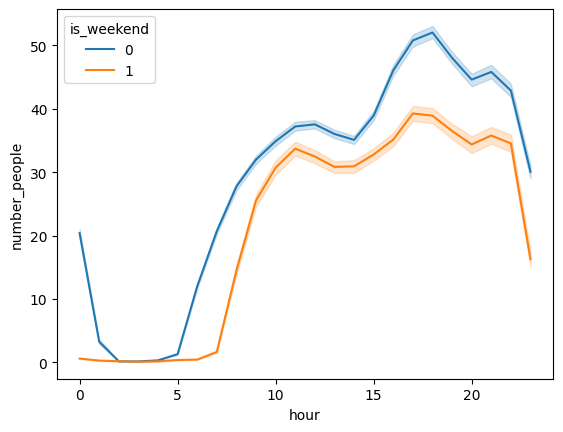

In [18]:
sns.lineplot(x='hour', y='number_people', data=df,hue='is_weekend')
plt.show()
# In evening hours gym likely to be more crowded. also on weekends.
# gym is less crowded compared to weekdays.

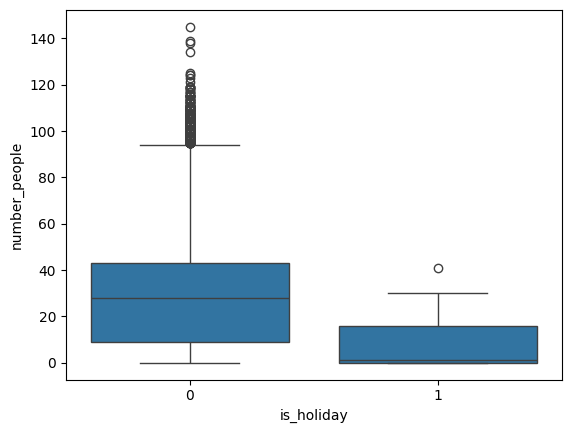

In [20]:
sns.boxplot(x='is_holiday', y='number_people', data=df)
plt.show()
#gym is less crowded on holidays.

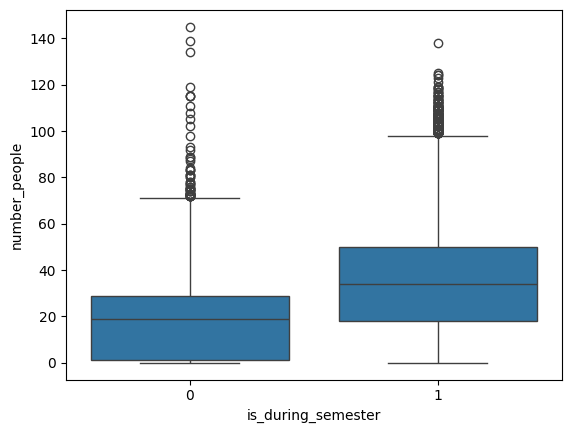

In [21]:
sns.boxplot(x='is_during_semester', y='number_people', data=df)
plt.show()
#gym is more crowded during semester. students are likely to go to gym more often.

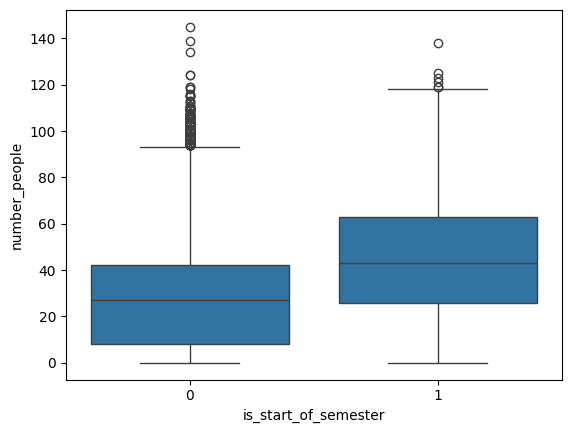

In [22]:
sns.boxplot(x='is_start_of_semester', y='number_people', data=df)
plt.show()
#gym is more crowded at the start of the semester. students are likely to go to gym more often.

<Axes: xlabel='day_of_week', ylabel='number_people'>

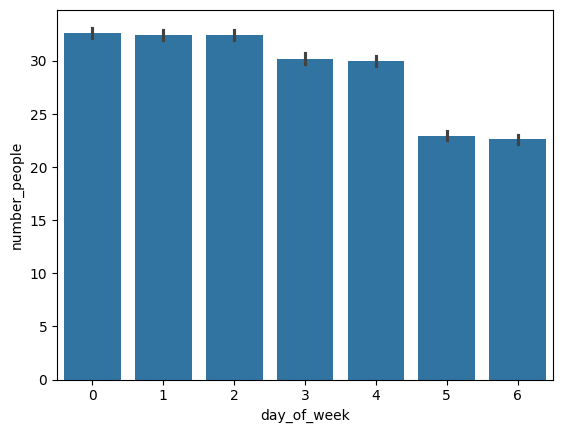

In [24]:
sns.barplot(data=df, x='day_of_week', y='number_people')
plt.show()
# gym is less crowded on weekends and last day of the week.

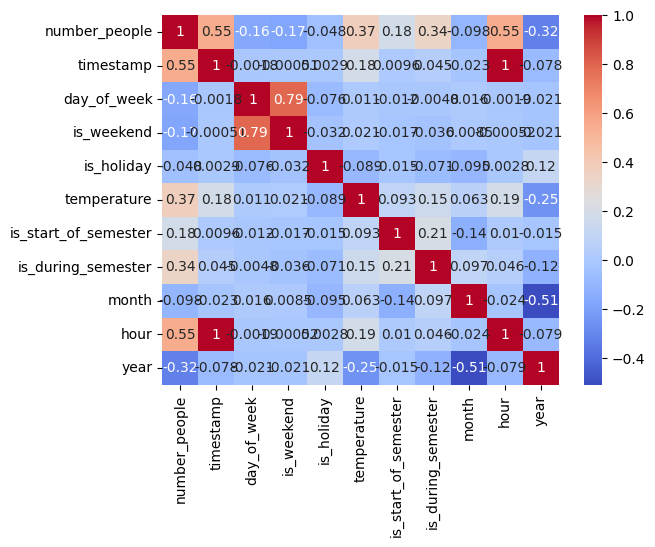

In [25]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()
# Timestamp and hour are highly correlated. we can drop timestamp column to avoid multicollinearity.

<Axes: xlabel='temperature', ylabel='number_people'>

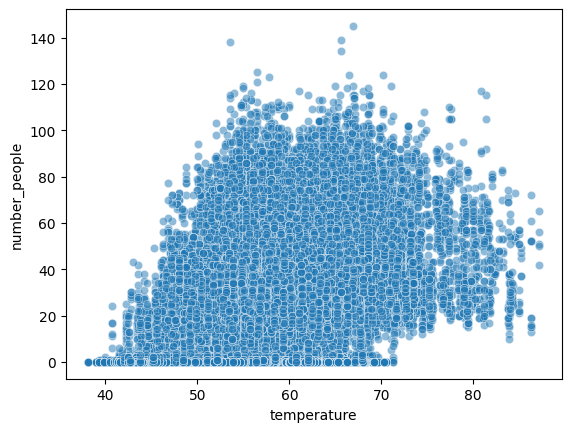

In [27]:
sns.scatterplot(data=df, x='temperature', y='number_people', alpha=0.5)

### Exploratory Data Analysis (EDA)
Visualizations revealed key insights: People tend to go gym evening hours and weekdays.Also they tend not to go gym on holidays and out of semester . We also explored timestamp and hour correlation is 1 so we have to drop one of them to avoid multicollinearity.

In [31]:
def correlation_for_dropping(data, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = data.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr # use these func when you want to drop highly correlated columns from your dataset to reduce multicollinearity and redundancy

In [32]:
colsToDrop = correlation_for_dropping(df, 0.85) # No highly correlated features to drop
print(colsToDrop) # hour or timestamp could be dropped but ı'll delete timestamp because hour more understanble column name.



{'hour'}


In [33]:
df.drop('timestamp', axis=1, inplace=True)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   day_of_week           62184 non-null  int64  
 2   is_weekend            62184 non-null  int64  
 3   is_holiday            62184 non-null  int64  
 4   temperature           62184 non-null  float64
 5   is_start_of_semester  62184 non-null  int64  
 6   is_during_semester    62184 non-null  int64  
 7   month                 62184 non-null  int64  
 8   hour                  62184 non-null  int64  
 9   year                  62184 non-null  int32  
dtypes: float64(1), int32(1), int64(8)
memory usage: 4.5 MB


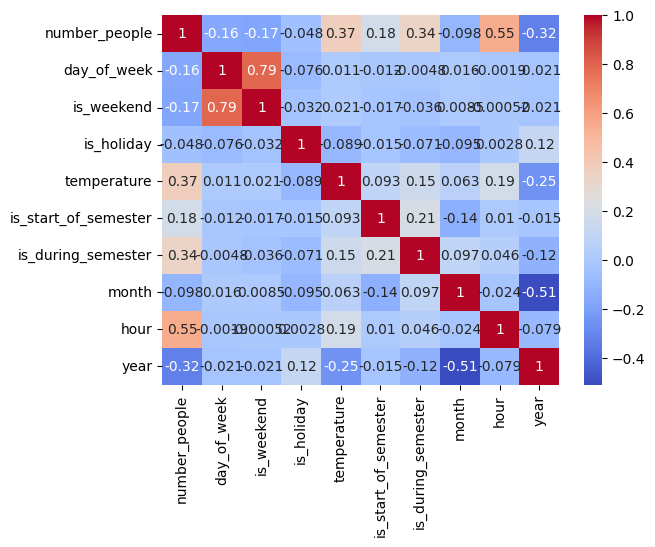

In [35]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

### Multicollinearity is destroyed
I delete timestamp column.

In [36]:
from sklearn.model_selection import train_test_split
X = df.drop('number_people', axis=1)
y = df['number_people']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Data Splitting and Scaling
I split the dataset into training and testing sets (75/25 split) and applied standard scaling to ensure all features contribute equally to the model training.

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [39]:
def calculate_model_metrics(true,predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    r2 = r2_score(true, predicted)
    adjusted_r2 = 1 - ( 1-r2 ) * ( len(true) - 1 ) / ( len(true) - X_test_scaled.shape[1] - 1 )
    return mae, mse, r2, adjusted_r2


### Evaluation Metrics Function
Defined a helper function to calculate key regression metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), R², and Adjusted R² for comprehensive performance tracking.

In [40]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

In [41]:
models = {
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'ElasticNet Regression': ElasticNet(),
    'KNN Regressor': KNeighborsRegressor(),
    'Support Vector Regressor': SVR(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42)
}

### Model Selection
Selected several regression algorithms, including Random Forest, Linear Regression, and SVR, to evaluate their baseline performance on the dataset.

In [44]:
for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred_train = model.predict(X_train_scaled) # Understanding overfitting & underfitting
    y_pred_test = model.predict(X_test_scaled)

    model_train_mae, model_train_mse, model_train_r2, model_train_adjusted_r2 = calculate_model_metrics(y_train, y_pred_train)
    model_test_mae, model_test_mse, model_test_r2, model_test_adjusted_r2 = calculate_model_metrics(y_test, y_pred_test)

    print(model_name)

    print('Evaluation on Training Set:')
    print(f'MAE: {model_train_mae:.2f}')
    print(f'MSE: {model_train_mse:.2f}')
    print(f'R²: {model_train_r2:.2f}')
    print(f'Adjusted R²: {model_train_adjusted_r2:.2f}')
    print('---')
    print('Evaluation on Test Set:')
    print(f'MAE: {model_test_mae:.2f}')
    print(f'MSE: {model_test_mse:.2f}')
    print(f'R²: {model_test_r2:.2f}')
    print(f'Adjusted R²: {model_test_adjusted_r2:.2f}')
    print('---')
    print('\n')

Random Forest Regressor
Evaluation on Training Set:
MAE: 3.23
MSE: 22.62
R²: 0.96
Adjusted R²: 0.96
---
Evaluation on Test Set:
MAE: 4.22
MSE: 39.17
R²: 0.92
Adjusted R²: 0.92
---


Linear Regression
Evaluation on Training Set:
MAE: 10.77
MSE: 207.02
R²: 0.60
Adjusted R²: 0.60
---
Evaluation on Test Set:
MAE: 10.67
MSE: 203.14
R²: 0.61
Adjusted R²: 0.61
---


Ridge Regression
Evaluation on Training Set:
MAE: 10.77
MSE: 207.02
R²: 0.60
Adjusted R²: 0.60
---
Evaluation on Test Set:
MAE: 10.67
MSE: 203.14
R²: 0.61
Adjusted R²: 0.61
---


Lasso Regression
Evaluation on Training Set:
MAE: 10.97
MSE: 214.17
R²: 0.58
Adjusted R²: 0.58
---
Evaluation on Test Set:
MAE: 10.88
MSE: 210.14
R²: 0.59
Adjusted R²: 0.59
---


ElasticNet Regression
Evaluation on Training Set:
MAE: 12.08
MSE: 247.31
R²: 0.52
Adjusted R²: 0.52
---
Evaluation on Test Set:
MAE: 12.06
MSE: 243.46
R²: 0.53
Adjusted R²: 0.53
---




/Users/ege/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ege/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ege/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ege/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ege/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ege/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid

KNN Regressor
Evaluation on Training Set:
MAE: 3.67
MSE: 29.78
R²: 0.94
Adjusted R²: 0.94
---
Evaluation on Test Set:
MAE: 4.74
MSE: 49.89
R²: 0.90
Adjusted R²: 0.90
---


Support Vector Regressor
Evaluation on Training Set:
MAE: 8.18
MSE: 135.26
R²: 0.74
Adjusted R²: 0.74
---
Evaluation on Test Set:
MAE: 8.09
MSE: 131.22
R²: 0.75
Adjusted R²: 0.75
---


Decision Tree Regressor
Evaluation on Training Set:
MAE: 3.20
MSE: 22.33
R²: 0.96
Adjusted R²: 0.96
---
Evaluation on Test Set:
MAE: 4.26
MSE: 40.38
R²: 0.92
Adjusted R²: 0.92
---




### Base Model Performances
The result are so similar in RandomForest Regressor and DecisionTreeRegressor. RandomForest slightly better.

In [45]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}
randomizedRandomForest = RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42), param_distributions=param_grid, n_iter=100, cv=5, verbose=2, random_state=42, n_jobs=-1)

### Hyperparameter Optimization
Configured a `RandomizedSearchCV` with a parameter grid to find the most effective settings for the Random Forest Regressor.

In [46]:
randomizedRandomForest.fit(X_train_scaled, y_train)
randomizedRandomForest.best_params_
randomizedRandomForest.best_score_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   2.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   2.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   2.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   2.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   2.0s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.4s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=4, min_samples_split=5, n_estimators=300; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=4, min_samples_split=5, n_estimato

/Users/ege/Library/Python/3.9/lib/python/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=300; total time=   6.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=  13.1s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=300; total time=   6.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=  13.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=  13.5s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   0.0s
[CV] END max_depth=None

/Users/ege/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
160 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
18 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/ege/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/ege/Library/Python/3.9/lib/python/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/Users/ege/Library/Python/3.9/lib/python/site-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
 

np.float64(0.91912774448293)

In [47]:
randomizedRandomForest.best_params_

{'n_estimators': 500,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': None}

In [48]:
y_pred = randomizedRandomForest.predict(X_test_scaled)
model_test_mae, model_test_mse, model_test_r2, model_test_adjusted_r2 = calculate_model_metrics(y_test, y_pred)
print('Evaluation on Test Set:')
print(f'MAE: {model_test_mae:.2f}')
print(f'MSE: {model_test_mse:.2f}')
print(f'R²: {model_test_r2:.2f}')
print(f'Adjusted R²: {model_test_adjusted_r2:.2f}')


Evaluation on Test Set:
MAE: 4.21
MSE: 38.97
R²: 0.92
Adjusted R²: 0.92


### Hyperparameter Tuning and Final Results
Using `RandomizedSearchCV`, we optimized the Random Forest Regressors' parameters. The final evaluation shows the performance improvements and the robustness of the tuned Random Forest model.
The hyperparameter tuning model is pretty slightly better mae score decreased 4.22 to 4.21